<a href="https://colab.research.google.com/github/fargonemaciel/infnet-machine-learning-codes/blob/main/feature_engineering_fargone_maciel_flor_DR2_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dados para Machine Learning: Feature Engineering [26E1_2]

### Teste de Performance - TP2 [OBRIGATÓRIO]

O arquivo ‘alexa.tsv’ contém uma amostra de avaliações feitas por clientes da Amazon sobre produtos adquiridos da linha Alexa, tais como Echo, Dot, Alexa, Fire, etc.

O arquivo está disponível na biblioteca Python kagglehub, sob o dataset "sid321axn/amazon-alexa-reviews".

O arquivo contém cerca de 3000 registros de avaliações, com as seguintes informações:

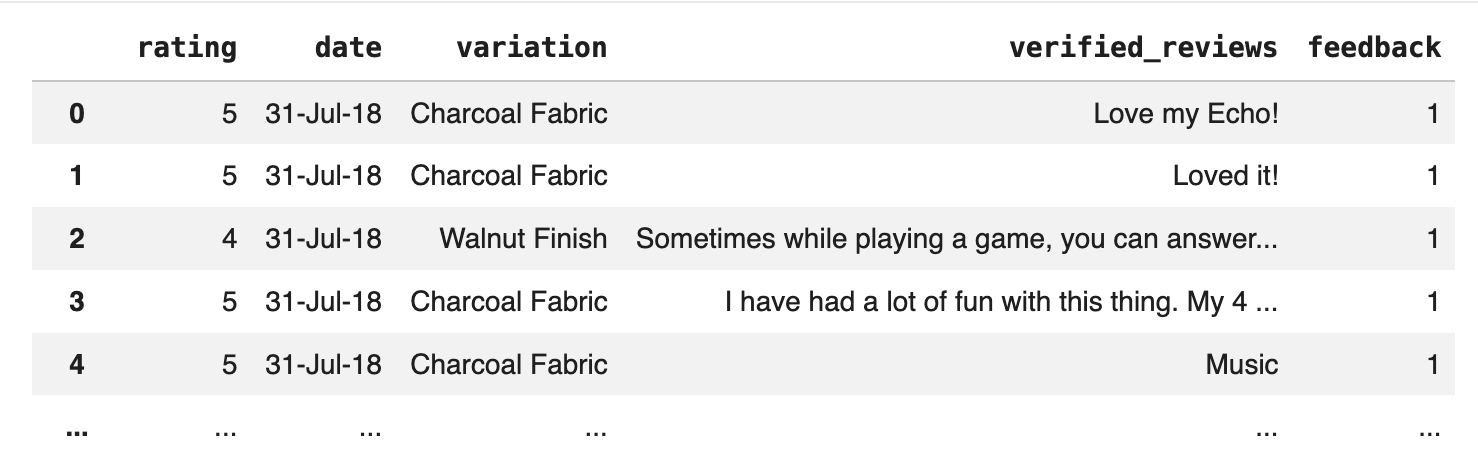

Utilizando python para processar este dataset com fins de análise de sentimento das avaliações, responda às perguntas de 1 a 9 a seguir. [Atenção: certifique-se de que o campo verified_reviews não contenha valores nulos e não faça distinção entre maiúsculas e minúsculas].

1. Crie uma representação vetorial do tipo bag-of-words para as avaliações textuais. Imprima o número de tokens obtido, bem como uma amostra de cerca de 50 a 100 palavras do seu vocabulário.
2. Crie uma representação vetorial do tipo bag-of-nGrams com bigramas para as avaliações textuais. Imprima o número de tokens obtido, bem como uma amostra com cerca de 50 a 100 bigramas do seu vetor.
3. Compare os resultados obtidos e opine sobre qual dos vetores seria melhor utilizar para uma análise de sentimento das avaliações: o de palavras ou o de bigramas, e por quê.
4. Remova as stopwords do seu corpus de avaliações e gere novos vetores de palavras e de bigramas, utilizando a lista sugerida de stopwords da nltk ou sklearn. Imprima os números de tokens obtidos e compare com os resultados de antes da remoção.
5. Em vez de empregar lista fixa de stopwords, remova palavras com baixíssima ou altíssima frequência no seu corpus de avaliações e gere novos vetores de palavras e de bigramas. Imprima os números de tokens obtidos e compare com os resultados de antes da remoção.
6. Compare os resultados das questões 4 e 5 e avalie e discuta, no caso deste dataset, qual seria a abordagem mais interessante para remover palavras de baixo valor semântico da análise.
7. Aplique a técnica de stemming sobre o texto das avaliações (já sem as stopwords ou palavras removidas por frequência – sua escolha). Imprima os números de tokens obtidos e compare com os resultados sem o stemming, indicando possíveis vantagens e desvantagens.
8. Aplique a lematização sobre o texto das avaliações (já sem as stopwords ou palavras removidas por frequência – sua escolha). Imprima os números de tokens obtidos e compare com os resultados antes da lematização, indicando possíveis vantagens e desvantagens.
9. Compare os resultados das questões 7 e 8 e avalie qual das técnicas – stemming ou lematização – representaria a melhor abordagem para uma análise de sentimento sobre este dataset.

In [1]:
# Libraries Import

import kagglehub
import os
import pandas as pd
import warnings
import nltk
import re

from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

warnings.filterwarnings("ignore")

In [2]:
path = kagglehub.dataset_download("sid321axn/amazon-alexa-reviews")
print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'amazon-alexa-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-alexa-reviews
['amazon_alexa.tsv']


In [3]:
df = pd.read_csv(path + "/amazon_alexa.tsv", sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [4]:
df.shape

(3150, 5)

In [5]:
# Verificando se há campos nulos em todos os campos

df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [6]:
# Cleaning the dataset

df_cleaned = df.dropna(subset=['verified_reviews'])

df_cleaned.isnull().sum()

df_cleaned['verified_reviews'] = df_cleaned['verified_reviews'].str.lower()

df_cleaned['verified_reviews']


,verified_reviews
0,love my echo!
1,loved it!
2,"sometimes while playing a game, you can answer..."
3,i have had a lot of fun with this thing. my 4 ...
4,music
...,...
3145,"perfect for kids, adults and everyone in betwe..."
3146,"listening to music, searching locations, check..."
3147,"i do love these things, i have them running my..."
3148,only complaint i have is that the sound qualit...


In [7]:
# Vectorizing and counting tokens

bow_converter = CountVectorizer()
bow_converter.fit(df_cleaned['verified_reviews'])
words = bow_converter.get_feature_names_out()

print(f"O número de tokens após a vetorização é de {len(words)} palavras")

O número de tokens após a vetorização é de 4044 palavras


In [8]:
# Visualizing one hundred words

words[590:690]

array(['cancel', 'canceling', 'cancelled', 'cancels', 'cannot', 'cant',
       'capabilities', 'capability', 'capable', 'capacity', 'capasity',
       'car', 'card', 'cards', 'cardsrotate', 'care', 'carefully',
       'careless', 'carful', 'carolina', 'carrier', 'carry', 'cart',
       'cartoons', 'case', 'cases', 'cat', 'catch', 'catches',
       'categories', 'cause', 'caused', 'cave', 'cbs', 'cd', 'ceases',
       'ceiling', 'ceilings', 'celebs', 'cell', 'cellphone', 'cent',
       'center', 'certain', 'certainly', 'certified', 'chachki', 'chair',
       'chalk', 'challenge', 'challenged', 'champ', 'chance', 'change',
       'changed', 'changer', 'changes', 'changing', 'channel', 'channels',
       'characteristics', 'charge', 'chargeable', 'charger', 'charging',
       'charlotte', 'charm', 'charmed', 'chart', 'chat', 'chatting',
       'cheap', 'cheaper', 'cheapest', 'check', 'checked', 'checking',
       'child', 'childhood', 'children', 'chocolate', 'choice', 'choices',
       '

In [9]:
# Vectorizing using Bag-of-nGrams

bigram_converter = CountVectorizer(ngram_range=(2,2))
bigram_converter.fit(df_cleaned['verified_reviews'])
bigrams = bigram_converter.get_feature_names_out()

print(f"O número de tokens após a vetorização é de {len(bigrams)} bigramas")

O número de tokens após a vetorização é de 27977 bigramas


In [10]:
# Visualizing one huundred bigrams

bigrams[590:690]

array(['after research', 'after researching', 'after return',
       'after school', 'after setting', 'after some', 'after something',
       'after sony', 'after talking', 'after tech', 'after the',
       'after their', 'after turn', 'after two', 'after visiting',
       'after we', 'after week', 'after weeks', 'after while',
       'after year', 'afternoon am', 'afterwards have', 'again also',
       'again and', 'again figured', 'again her', 'again highly',
       'again it', 'again later', 'again lol', 'again love', 'again or',
       'again shortly', 'again so', 'again that', 'again then',
       'again this', 'again to', 'again total', 'again was',
       'again watched', 'again we', 'again when', 'again will',
       'agent man', 'ages ago', 'ago everything', 'ago love', 'ago on',
       'ago the', 'ago wish', 'ago with', 'ago yesterday',
       'agree youtube', 'agreement expires', 'ahead and', 'ahead of',
       'ai built', 'ai gets', 'ai in', 'ai or', 'ai system', 'aide my',

**Resposta da 3ª Questão**: Ao usarmos a vetorização com bigramas, a contagem de tokens passou de 4.044 para 27.977, o que aumenta em muito o campo semântico de compreensão. Por exemplo, veja o bigrama 'agreement expires', se pegássemos apenas as duas palavras isoladamente o risco de má interpretação é altíssimo. Portanto, utilizar bigrama atende melhor uma análise de sentimento das reviews por essa questão semântica.

In [11]:
# Removing Stopwords

nltk.download('stopwords')

stop_words = stopwords.words('english')

stop_words[:10]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [12]:
#Creating review column with no stopwords

pattern = r'\b(?:' + '|'.join(re.escape(word) for word in stop_words) + r')\b'

df_cleaned['verified_reviews_nostop'] = df_cleaned['verified_reviews'].str.replace(pattern, '', regex=True, case=False)

df_cleaned['verified_reviews_nostop'] = df_cleaned['verified_reviews_nostop'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [13]:
df_cleaned.head()

,rating,date,variation,verified_reviews,feedback,verified_reviews_nostop
0,5,31-Jul-18,Charcoal Fabric,love my echo!,1,love echo!
1,5,31-Jul-18,Charcoal Fabric,loved it!,1,loved !
2,4,31-Jul-18,Walnut Finish,"sometimes while playing a game, you can answer...",1,"sometimes playing game, answer question correc..."
3,5,31-Jul-18,Charcoal Fabric,i have had a lot of fun with this thing. my 4 ...,1,"lot fun thing. 4 yr old learns dinosaurs, cont..."
4,5,31-Jul-18,Charcoal Fabric,music,1,music


In [14]:
# Vectorizing no Stopwords Column

bow_converter.fit(df_cleaned['verified_reviews_nostop'])
words_nostop = bow_converter.get_feature_names_out()

print(f"O número de tokens após vetorização e remoção de stopwords é de {len(words_nostop)} palavras")

O número de tokens após vetorização e remoção de stopwords é de 3908 palavras


In [15]:
# Vectorizing bigrams de no Stopwords Column

bigram_converter.fit(df_cleaned['verified_reviews_nostop'])
bigrams_nostop = bigram_converter.get_feature_names_out()

print(f"O número de tokens após vetorização e remoção de stopwords é de {len(bigrams_nostop)} bigramas")

O número de tokens após vetorização e remoção de stopwords é de 22270 bigramas


In [16]:
# Analysing differences after removing no stopwords

print(f"Diferença de palavras: {len(words) - len(words_nostop)}")
print(f"Diferença de bigramas: {len(bigrams) - len(bigrams_nostop)}")

Diferença de palavras: 136
Diferença de bigramas: 5707


**Análise comparativa**: Remover stopwords ajudou a diminuir as matrizes de palavras e melhoram o campo semântico de entendimento dos textos

In [17]:
# Removing words that appers one time and the two porcent most frequently words

bow_converter = CountVectorizer(min_df=2, max_df=.2)
bigram_converter = CountVectorizer(ngram_range=(2,2), min_df=2, max_df=.2)

bow_converter.fit(df_cleaned['verified_reviews'])
bigram_converter.fit(df_cleaned['verified_reviews'])

words_freq = bow_converter.get_feature_names_out()
bigrams_freq = bigram_converter.get_feature_names_out()

print(f"O número de tokens após vetorização e remoção de stopwords é de {len(words_freq)} palavras")
print(f"O número de tokens após vetorização e remoção de stopwords é de {len(bigrams_freq)} bigramas")

O número de tokens após vetorização e remoção de stopwords é de 2505 palavras
O número de tokens após vetorização e remoção de stopwords é de 11338 bigramas


In [18]:
# Analysing differences after removing one word only and the two percent higher frequent words

print(f"Diferença de palavras: {len(words) - len(words_freq)}")
print(f"Diferença de bigramas: {len(bigrams) - len(bigrams_freq)}")

Diferença de palavras: 1539
Diferença de bigramas: 16639


In [19]:
bigrams_nostop[:500]

array(['00 hard', '00 less', '00 sale', '000 sure', '07 23', '10 00',
       '10 10', '10 20', '10 30pm', '10 always', '10 cheaper',
       '10 connect', '10 days', '10 degrees', '10 minutes', '10 must',
       '10 questions', '10 recommend', '10 year', '10 years',
       '100 amazon', '100 another', '100 chance', '100 hub', '100 know',
       '100 learn', '100 opinion', '100 piece', '100 prime', '100 range',
       '100 sale', '100 spent', '100 time', '100x better', '11 yr',
       '1100sf sitting', '12 20', '129 good', '12am every', '15 discount',
       '15 minute', '15 minutes', '150 highly', '150 pretty', '18 parts',
       '19 best', '19 mins', '1964 54', '1990 downright', '1990 simple',
       '1gb memory', '1rst gen', '1st aux', '1st echo', '1st gen',
       '1st generation', '1st season', '20 30', '20 beat', '20 bucks',
       '20 dollars', '20 less', '20 prime', '20 stands', '20 time',
       '20 times', '20 years', '200 bucks', '2000 miles', '2017 aware',
       '229 price',

In [20]:
bigrams_freq[:500]

array(['00 on', '10 10', '10 questions', '10 recommend', '10 to',
       '10 which', '100 on', '100 we', '11 yr', '1100sf and',
       '15 minutes', '1990 and', '1st but', '1st gen', '1st generation',
       '20 dollars', '2nd echo', '2nd gen', '2nd generation', '2nd issue',
       '2nd one', '30 can', '30 minutes', '30 years', '34 2nd', '34 34',
       '34 alexa', '34 and', '34 are', '34 as', '34 but', '34 can',
       '34 computer', '34 don', '34 dot', '34 echo', '34 for', '34 get',
       '34 group', '34 half', '34 have', '34 home', '34 in', '34 instead',
       '34 it', '34 late', '34 listen', '34 love', '34 me', '34 minor',
       '34 not', '34 on', '34 one', '34 or', '34 outlet', '34 screen',
       '34 she', '34 smart', '34 so', '34 sorry', '34 sounds',
       '34 spying', '34 the', '34 thick', '34 things', '34 to', '34 try',
       '34 understand', '34 wake', '34 warehouse', '34 when', '34 with',
       '39 99', '3rd dot', '3rd echo', '3rd party', '4am and', '4ghz and',
       

**Análise comparativa**: Remover palavras únicas e os 2% de palavras mais frenquentes, trouxe uma diminuição considerável na quantidade de tokens. Só no olho não é possível bater o martelo em qual forma é a melhor para a questão neste momento, só com o treino posterior do modelo e comparativos de acurácia.

In [21]:
# Applying Stemming to the Reviews

vectorizer = CountVectorizer(min_df=5, stop_words='english')

matriz_esparsa = vectorizer.fit_transform(df_cleaned['verified_reviews'])

print(f"Número de reviews: {matriz_esparsa.shape[0]}")
print(f"Número de tokens: {matriz_esparsa.shape[1]}")

Número de reviews: 3149
Número de tokens: 1028


In [22]:
matriz_esparsa.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [23]:
df_matriz_esparsa = pd.DataFrame(matriz_esparsa.toarray(), columns=vectorizer.get_feature_names_out())
df_matriz_esparsa.tail()

,10,100,1st,20,2nd,30,34,3rd,99,ability,...,world,worried,worry,worth,wouldn,wrong,year,years,yes,youtube
3144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3145,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3146,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3147,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
contagens = df_matriz_esparsa.sum()
contagens.sort_values(ascending=False)

,0
love,956
echo,839
great,729
alexa,632
music,540
...,...
anymore,5
anticipated,5
willing,5
act,5


In [25]:
contagens = matriz_esparsa.sum(axis=0)
contagens = contagens.tolist()[0]
len(contagens)

1028

In [26]:
tokens = vectorizer.get_feature_names_out()

tokens[-50:-1]

array(['volume', 'wait', 'waiting', 'wake', 'waking', 'walk', 'wall',
       'want', 'wanted', 'warranty', 'wasn', 'waste', 'watch', 'watching',
       'wave', 'way', 'ways', 'weak', 'weather', 'web', 'week', 'weekend',
       'weeks', 'weird', 'went', 'white', 'wi', 'wife', 'wifi', 'willing',
       'wireless', 'wish', 'won', 'wonderful', 'word', 'words', 'work',
       'worked', 'working', 'works', 'world', 'worried', 'worry', 'worth',
       'wouldn', 'wrong', 'year', 'years', 'yes'], dtype=object)

In [27]:
freq = [(word, count) for word, count in zip(tokens, contagens)]
freq = sorted(freq, key=lambda x: x[1], reverse=True)
freq[0:25]

[('love', 956),
 ('echo', 839),
 ('great', 729),
 ('alexa', 632),
 ('music', 540),
 ('like', 504),
 ('use', 469),
 ('works', 381),
 ('easy', 342),
 ('sound', 340),
 ('just', 334),
 ('set', 306),
 ('dot', 286),
 ('good', 277),
 ('amazon', 258),
 ('product', 258),
 ('speaker', 241),
 ('34', 219),
 ('home', 217),
 ('device', 215),
 ('play', 215),
 ('time', 197),
 ('really', 193),
 ('bought', 189),
 ('smart', 184)]

In [28]:
# Stemming

nltk.download('punkt_tab', quiet=True)

stemmer = PorterStemmer()

def stem_text(text):
  if not isinstance(text, str):
    return ""
  pretokens = word_tokenize(text.lower())
  stemmed = [stemmer.stem(token) for token in pretokens]
  return " ".join(stemmed)

df_cleaned['verified_reviews_stemmed'] = df_cleaned['verified_reviews'].apply(stem_text)

In [29]:
df_cleaned['verified_reviews_stemmed']

,verified_reviews_stemmed
0,love my echo !
1,love it !
2,"sometim while play a game , you can answer a q..."
3,i have had a lot of fun with thi thing . my 4 ...
4,music
...,...
3145,"perfect for kid , adult and everyon in between..."
3146,"listen to music , search locat , check time , ..."
3147,"i do love these thing , i have them run my ent..."
3148,onli complaint i have is that the sound qualit...


In [30]:
# Lemmatization

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text_simple(text):
  if not isinstance(text, str):
    return ""
  pretokens = word_tokenize(text.lower())
  lemmas = [lemmatizer.lemmatize(token) for token in pretokens]
  return " ".join(lemmas)

df_cleaned['verified_reviews_lemmatized'] = df_cleaned['verified_reviews'].apply(lemmatize_text_simple)

In [31]:
df_cleaned['verified_reviews_lemmatized']

,verified_reviews_lemmatized
0,love my echo !
1,loved it !
2,"sometimes while playing a game , you can answe..."
3,i have had a lot of fun with this thing . my 4...
4,music
...,...
3145,"perfect for kid , adult and everyone in betwee..."
3146,"listening to music , searching location , chec..."
3147,"i do love these thing , i have them running my..."
3148,only complaint i have is that the sound qualit...


In [33]:
# Comparing the results of the three methods

matriz_esparsa_stemmed = vectorizer.fit_transform(df_cleaned['verified_reviews_stemmed'])
token_stem = vectorizer.get_feature_names_out()

matriz_esparsa_lemmatized = vectorizer.fit_transform(df_cleaned['verified_reviews_lemmatized'])
token_lemma = vectorizer.get_feature_names_out()

print(f"Original Method: {matriz_esparsa.shape}")
print(f"Stemming Method: {matriz_esparsa_stemmed.shape}")
print(f"Lemmatization Method: {matriz_esparsa_lemmatized.shape}")

Original Method: (3149, 1028)
Stemming Method: (3149, 891)
Lemmatization Method: (3149, 958)


**Comparação**: Tecnicamente, usar a lematização costuma performar melhor que os demais formatos propostos. Só pela quantidade de tokens gerado com o método não conseguimos fechar com certeza a escolha sem testar nos modelos e via acurácia.